## 3. Modeling TF-IDF x LSTM

### 3.1 Importing the Libraries 

In [36]:
import pickle
import os 
import matplotlib.pyplot as plt
import numpy as np 
import seaborn as sns 

from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Dense, Embedding, LSTM, Input, Concatenate, Dropout)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import AdamW 

### 3.2 Define the Parameter

In [37]:
VOCAB_SIZE = 5000
TFIDF_FEATURES = 5000
MAX_LEN = 200
MODEL_SAVE_PATH = "../models/lstm_model.keras"

### 3.2 Load the Dataset

In [38]:
# X_train_pad   = pickle.load(open("../dataset/processed/02_after_FE/X_train_pad.pkl", "rb"))
# X_train_tfidf = pickle.load(open("../dataset/processed/02_after_FE/X_train_tfidf.pkl", "rb"))
# y_train       = pickle.load(open("../dataset/processed/02_after_FE/y_train.pkl", "rb"))

# X_test_pad    = pickle.load(open("../dataset/processed/02_after_FE/X_test_pad.pkl", "rb"))
# X_test_tfidf  = pickle.load(open("../dataset/processed/02_after_FE/X_test_tfidf.pkl", "rb"))
# y_test        = pickle.load(open("../dataset/processed/02_after_FE/y_test.pkl", "rb"))

In [39]:
# ### 3.2 Load the Dataset (UPDATE)

# --- Train ---
X_train_pad   = pickle.load(open("../dataset/processed/02_after_FE/X_train_pad.pkl", "rb"))
X_train_tfidf = pickle.load(open("../dataset/processed/02_after_FE/X_train_tfidf.pkl", "rb"))
y_train       = pickle.load(open("../dataset/processed/02_after_FE/y_train.pkl", "rb"))

# --- Validation (BARU DITAMBAHKAN) ---
X_val_pad     = pickle.load(open("../dataset/processed/02_after_FE/X_val_pad.pkl", "rb"))
X_val_tfidf   = pickle.load(open("../dataset/processed/02_after_FE/X_val_tfidf.pkl", "rb"))
y_val         = pickle.load(open("../dataset/processed/02_after_FE/y_val.pkl", "rb"))

# --- Test ---
X_test_pad    = pickle.load(open("../dataset/processed/02_after_FE/X_test_pad.pkl", "rb"))
X_test_tfidf  = pickle.load(open("../dataset/processed/02_after_FE/X_test_tfidf.pkl", "rb"))
y_test        = pickle.load(open("../dataset/processed/02_after_FE/y_test.pkl", "rb"))

### 3.3 Konversi Data Type

In [40]:
# # Input Sequence (X_pad) HARUS INT32 untuk Embedding Layer
# X_train_pad   = np.array(X_train_pad, dtype='int32') 
# X_test_pad    = np.array(X_test_pad, dtype='int32')   

# # Input TFIDF dan Label tetap FLOAT32
# X_train_tfidf = np.array(X_train_tfidf, dtype='float32')
# X_test_tfidf  = np.array(X_test_tfidf, dtype='float32')

# y_train = np.array(y_train, dtype='float32')
# y_test  = np.array(y_test, dtype='float32')

In [41]:
# ### 3.3 Konversi Data Type (UPDATE)

# Input Sequence (X_pad) HARUS INT32 untuk Embedding Layer
X_train_pad = np.array(X_train_pad, dtype='int32')
X_val_pad   = np.array(X_val_pad, dtype='int32')   # BARU
X_test_pad  = np.array(X_test_pad, dtype='int32')

# Input TFIDF dan Label tetap FLOAT32
X_train_tfidf = np.array(X_train_tfidf, dtype='float32')
X_val_tfidf   = np.array(X_val_tfidf, dtype='float32') # BARU
X_test_tfidf  = np.array(X_test_tfidf, dtype='float32')

y_train = np.array(y_train, dtype='float32')
y_val   = np.array(y_val, dtype='float32')         # BARU
y_test  = np.array(y_test, dtype='float32')

### 3.4 Check Array Dimension

In [42]:
print(f"Shape X_train_pad: {X_train_pad.shape}")
print(f"Shape X_train_tfidf: {X_train_tfidf.shape}")
print(f"Shape y_train: {y_train.shape}")
print(f"Shape y_test: {y_test.shape}")

Shape X_train_pad: (30816, 200)
Shape X_train_tfidf: (30816, 5000)
Shape y_train: (30816,)
Shape y_test: (2089,)


In [43]:
# === ASSERTION CHECK (important!) ===
assert X_train_pad.shape[0] == X_train_tfidf.shape[0] == y_train.shape[0], \
    "Mismatch: jumlah sample antara sequence, tfidf, dan label tidak sama!"

assert X_test_pad.shape[0] == X_test_tfidf.shape[0] == y_test.shape[0], \
    "Mismatch: jumlah sample test tidak sama!"

### 3.4 Build LSTM Model with TF-IDF

In [44]:
# # Sequence
# input_seq = Input(shape=(MAX_LEN,), name='input_sequence')

# x = Embedding(input_dim=VOCAB_SIZE, output_dim=64)(input_seq) 

# x = LSTM(32)(x) 
# x = Dropout(0.5)(x) 

# # TF-IDF 
# input_tfidf = Input(shape=(TFIDF_FEATURES,), name='input_tfidf') 
# y = Dense(16, activation='relu')(input_tfidf) 
# y = Dropout(0.3)(y) # Tambah dikit biar imbang sama sequence

# # Concate
# combined = Concatenate()([x, y])

# z = Dense(32, activation="relu")(combined) 
# z = Dropout(0.5)(z) 
# output_layer = Dense(1, activation="sigmoid")(z)

# # Define model
# model = Model(inputs=[input_seq, input_tfidf], outputs=output_layer)

# optimizer = AdamW(learning_rate=0.0001, weight_decay=0.004)

# model.compile(
#     loss='binary_crossentropy',
#     optimizer=optimizer, 
#     metrics=['accuracy']
# )
# print(model.summary())

In [45]:
# %%
# === JANGAN LUPA IMPORT INI ===
from tensorflow.keras.regularizers import l2

# ... (pastikan library lain sudah terimport) ...

# %%
# Sequence Branch
input_seq = Input(shape=(MAX_LEN,), name='input_sequence')

x = Embedding(input_dim=VOCAB_SIZE, output_dim=64)(input_seq) 

# UBAH 1: Tambah L2 Regularizer di LSTM
x = LSTM(32, kernel_regularizer=l2(0.01))(x) 
x = Dropout(0.5)(x) 

# TF-IDF Branch
input_tfidf = Input(shape=(TFIDF_FEATURES,), name='input_tfidf') 

# UBAH 2: Tambah L2 Regularizer di Dense
y = Dense(16, activation='relu', kernel_regularizer=l2(0.01))(input_tfidf) 
# UBAH 3: Naikkan Dropout jadi 0.5 (biar imbang)
y = Dropout(0.5)(y) 

# Concate
combined = Concatenate()([x, y])

# Combined Dense Layer
# UBAH 4: Tambah L2 Regularizer di sini juga
z = Dense(32, activation="relu", kernel_regularizer=l2(0.01))(combined) 
z = Dropout(0.5)(z) 

output_layer = Dense(1, activation="sigmoid")(z)

# Define model
model = Model(inputs=[input_seq, input_tfidf], outputs=output_layer)

# UBAH 5: Perlambat Learning Rate (0.00001)
optimizer = AdamW(learning_rate=0.00001, weight_decay=0.004)

model.compile(
    loss='binary_crossentropy',
    optimizer=optimizer, 
    metrics=['accuracy']
)
print(model.summary())

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_sequence      │ (None, 200)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 200, 64)   │    320,000 │ input_sequence[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_tfidf         │ (None, 5000)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 32)        │     12,416 │ embedding_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 16)        │     80,016 │ input_tfidf[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 32)        │          0 │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 16)        │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 48)        │          0 │ dropout_6[0][0],  │
│ (Concatenate)       │                   │            │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 32)        │      1,568 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 32)        │          0 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 1)         │         33 │ dropout_8[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 414,033 (1.58 MB)

 Trainable params: 414,033 (1.58 MB)

 Non-trainable params: 0 (0.00 B)

None


### 3.5 Define Callbacks

In [46]:
early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=3, 
    restore_best_weights=True,
    verbose=1
)

### 3.6 Training

In [47]:
# history = model.fit(
#     [X_train_pad, X_train_tfidf],
#     y_train,
#     validation_split=0.2,
#     epochs=50,
#     batch_size=64,
#     callbacks=[early_stopping],
#     verbose=1
# )

In [48]:
# ### 3.6 Training (UPDATE)

history = model.fit(
    [X_train_pad, X_train_tfidf],
    y_train,
    # --- GANTI BAGIAN INI ---
    validation_data=([X_val_pad, X_val_tfidf], y_val), 
    # validation_split=0.2,  <-- HAPUS INI
    # ------------------------
    epochs=100,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
482/482 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.5473 - loss: 2.1426 - val_accuracy: 0.8138 - val_loss: 2.0482
Epoch 2/100
482/482 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.6352 - loss: 1.9684 - val_accuracy: 0.9387 - val_loss: 1.8895
Epoch 3/100
482/482 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7084 - loss: 1.8251 - val_accuracy: 0.9617 - val_loss: 1.7538
Epoch 4/100
482/482 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7610 - loss: 1.7009 - val_accuracy: 0.9019 - val_loss: 1.6280
Epoch 5/100
482/482 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7725 - loss: 1.5743 - val_accuracy: 0.7563 - val_loss: 1.5140
Epoch 6/100
482/482 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8142 - loss: 1.4337 - val_accuracy: 0.8143 - val_loss: 1.3274
Epoch 7/100
482/482 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8817 - loss: 1.2749 - val_accuracy: 0.9607 - val_loss: 1.0898
Epoch 8/100
482/482 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9098 - loss: 1.1515 - val_accu

### 3.7 Evaluation

In [49]:
loss, acc = model.evaluate([X_test_pad, X_test_tfidf], y_test, verbose=1)
print(f"\nAkurasi Test (LSTM + TF-IDF): {acc:.4f}")

66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9823 - loss: 0.1897

Akurasi Test (LSTM + TF-IDF): 0.9823


#### 3.7.1 Training and Validation Loss

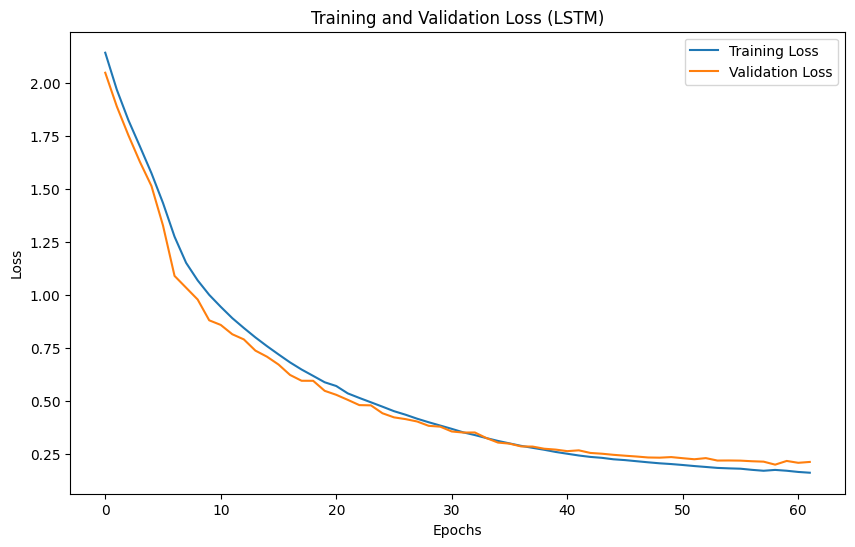

In [50]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss (LSTM)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

#### 3.7.2 Confusion Matrix

66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


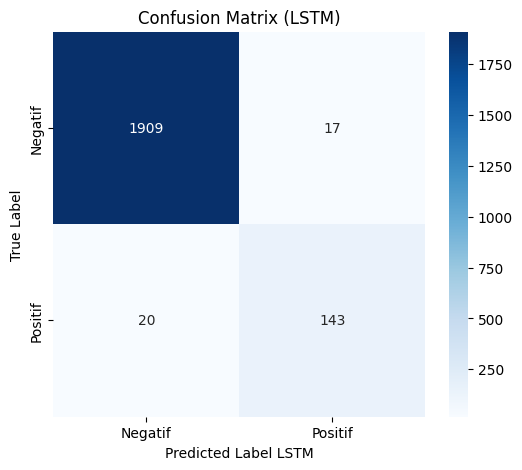

              precision    recall  f1-score   support

     Negatif       0.99      0.99      0.99      1926
     Positif       0.89      0.88      0.89       163

    accuracy                           0.98      2089
   macro avg       0.94      0.93      0.94      2089
weighted avg       0.98      0.98      0.98      2089



In [54]:
y_pred_prob = model.predict([X_test_pad, X_test_tfidf])
y_pred = (y_pred_prob > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negatif', 'Positif'],
            yticklabels=['Negatif', 'Positif'])
plt.title('Confusion Matrix (LSTM)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label LSTM')
plt.show()

print(classification_report(y_test, y_pred, target_names=['Negatif', 'Positif']))

### 3.8 Save Model

In [52]:
os.makedirs("../models", exist_ok=True) 
model.save(MODEL_SAVE_PATH)
print("Model LSTM saved to:", MODEL_SAVE_PATH)

Model LSTM saved to: ../models/lstm_model.keras


### 3.9 Addition

In [53]:
best_epoch_index = np.argmin(history.history['val_loss'])
best_val_loss = history.history['val_loss'][best_epoch_index]

print(f"Model mulai menghafal sekitar epoch: {best_epoch_index + 1}")
print(f"Validation Loss terendah (Best Epoch): {best_val_loss:.4f}")

Model mulai menghafal sekitar epoch: 59
Validation Loss terendah (Best Epoch): 0.1995
